In [1]:
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import os, math, copy
import torchaudio, torch, torch.nn as nn
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import get_cosine_schedule_with_warmup
from torchmetrics import Accuracy, F1Score, Precision, Recall

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

In [2]:
class config:
    base_audio_dir="/kaggle/input/datasets/pythonafroz/electrical-motor-operational-state-sound-data/IDMT-ISA-ELECTRIC-ENGINE"

    n_fft=1024
    hop_length=1024//2
    n_mels=80
    sampling_rate=16_000

    n_class = 3
    batch_size = 5
    input_size = 80

    n_lstm_layer = 2
    lstm_hidden_size = 512

    n_gru_layer = 2
    gru_hidden_size = 512

    n_lstm_gru_layer = 2
    lstm_gru_hidden_size = 512

    in_channel = 1
    embed_dim = 1024
    patch_size = 16
    num_head = 16
    n_blocks = 12
    max_seq_len = 2048

    n_epochs = 100

    device_1 = "cuda:0"
    device_2 = "cuda:1"
    
    patience = 10
    min_delta = 1e-4

In [3]:
def GetData(path):
    train_cut, test_cut, train, test = [], [], [], []
    for folder in os.listdir(path):
        if folder == "test_cut":
            test_cut_dir = os.path.join(path, folder)
            audios = glob(test_cut_dir+"/**/**.wav")
            test_cut.extend(audios)
        elif folder == "train_cut":
            train_cut_dir = os.path.join(path, folder)
            audios = glob(train_cut_dir+"/**/**.wav")
            train_cut.extend(audios)
        elif folder == "test":
            test_dir = os.path.join(path, folder)
            audios = glob(test_dir+"/**/**.wav")
            test.extend(audios)
        elif folder == "train":
            train_dir = os.path.join(path, folder)
            audios = glob(train_dir+"/**/**.wav")
            train.extend(audios)
        else:
            continue
    return pd.DataFrame(train_cut), pd.DataFrame(test_cut), pd.DataFrame(train), pd.DataFrame(test)

In [4]:
train_cut_df, test_cut_df, train_df, test_df = GetData(config.base_audio_dir)

In [5]:
train_cut_df[1] = train_cut_df[0].apply(lambda x: x.split("/")[-2])
train_cut_df.columns = ["path", "label"]

test_cut_df[1] = test_cut_df[0].apply(lambda x: x.split("/")[-2])
test_cut_df.columns = ["path", "label"]

train_df[1] = train_df[0].apply(lambda x: x.split("/")[-2])
train_df.columns = ["path", "label"]

test_df[1] = test_df[0].apply(lambda x: x.split("/")[-2])
test_df.columns = ["path", "label"]

In [6]:
encoder = LabelEncoder()

comb_df = pd.concat([test_cut_df, train_cut_df]).reset_index(drop=True)

comb_df["label_enc"] = encoder.fit_transform(comb_df["label"])

comb_df.head()

,path,label,label_enc
0,/kaggle/input/datasets/pythonafroz/electrical-...,engine3_heavyload,2
1,/kaggle/input/datasets/pythonafroz/electrical-...,engine3_heavyload,2
2,/kaggle/input/datasets/pythonafroz/electrical-...,engine3_heavyload,2
3,/kaggle/input/datasets/pythonafroz/electrical-...,engine3_heavyload,2
4,/kaggle/input/datasets/pythonafroz/electrical-...,engine3_heavyload,2


In [7]:
idx_2_label = {i:j for i, j in zip(range(len(encoder.classes_)), encoder.classes_)}

idx_2_label

{0: 'engine1_good', 1: 'engine2_broken', 2: 'engine3_heavyload'}

In [8]:
xtrain, xval = train_test_split(comb_df, test_size=0.1, stratify=comb_df["label_enc"])

xtrain.reset_index(drop=True, inplace=True)
xval.reset_index(drop=True, inplace=True)

print(xtrain.shape, xval.shape)

(2140, 3) (238, 3)


In [9]:
class AudioDataset(Dataset):
    def __init__(self, df, config):
        self.data = df
        mel_spec_trans = torchaudio.transforms.MelSpectrogram(sample_rate=config.sampling_rate,
                                                              n_fft=config.n_fft,
                                                              hop_length=config.hop_length, 
                                                              n_mels=config.n_mels)
        self.mels = []
        for idx, rows in self.data.iterrows():
            wave, sr = torchaudio.load(rows["path"])

            if sr != config.sampling_rate:
                resample = torchaudio.transforms.Resample(sr, config.sampling_rate)
                wave = resample(wave)

            if wave.shape[0] > 1:
                wave = wave.mean(dim=0, keepdim=True)

            mel = torch.log1p(mel_spec_trans(wave))

            mel_norm = (mel - mel.mean()) / (mel.std() + 1e-1) # (channel, n_mels, time_frame)

            self.mels.append((mel_norm.transpose(1, 2), rows["label_enc"]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # X -> (channel, time_frame, n_mels)
        X, y = self.mels[idx]
        return X, torch.tensor(y, dtype=torch.long)

In [10]:
def collate_fn(batch):
    x, y = zip(*batch)
    max_audio_len = max(i.shape[1] for i in x)
    n_mels = x[0].shape[-1]
    padded_x = torch.zeros(len(x), 1, max_audio_len, n_mels)
    
    for i, j in enumerate(x):
        t = j.shape[-2]
        padded_x[i, :, :t, :] = j

    return padded_x, torch.tensor(y)
        

train_ds = AudioDataset(df=xtrain, config=config)
train_dl = DataLoader(train_ds, 
                      batch_size=config.batch_size, 
                      shuffle=True, 
                      collate_fn=collate_fn,
                      num_workers=os.cpu_count())

val_ds = AudioDataset(df=xval, config=config)
val_dl = DataLoader(val_ds, 
                    batch_size=config.batch_size, 
                    shuffle=False, 
                    collate_fn=collate_fn,
                    num_workers=os.cpu_count())

In [11]:
batch_x, batch_y = next(iter(train_dl))

print(batch_x.shape, batch_y.shape)

torch.Size([5, 1, 94, 80]) torch.Size([5])


In [12]:
class GRUModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_gru_layer):
            inp = config.input_size if i == 0 else 2*config.gru_hidden_size
            self.layers.append(
                nn.GRU(inp, config.gru_hidden_size, batch_first=True, bidirectional=True)
            )
        self.ln = nn.LayerNorm(2*config.gru_hidden_size)
        
        self.out_proj = nn.Linear(2*config.gru_hidden_size, config.n_class)

    @property
    def name(self):
        return "gru_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_lstm_layer):
            inp = config.input_size if i == 0 else 2*config.lstm_hidden_size
            self.layers.append(
                nn.LSTM(inp, config.lstm_hidden_size, batch_first=True, bidirectional=True)
            )
        self.ln = nn.LayerNorm(2*config.lstm_hidden_size)
        
        self.out_proj = nn.Linear(2*config.lstm_hidden_size, config.n_class)

    @property
    def name(self):
        return "lstm_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]

In [14]:
class LSTMGRUModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_lstm_gru_layer):
            inp = config.input_size if i == 0 else 2*config.lstm_gru_hidden_size
            self.layers.append(
                nn.LSTM(inp, config.lstm_gru_hidden_size, batch_first=True, bidirectional=True)
            )
            self.layers.append(
                nn.GRU(2*config.lstm_gru_hidden_size, config.lstm_gru_hidden_size, batch_first=True, bidirectional=True)
            )
        self.ln = nn.LayerNorm(2*config.lstm_gru_hidden_size)
        
        self.out_proj = nn.Linear(2*config.lstm_gru_hidden_size, config.n_class)

    @property
    def name(self):
        return "lstm_gru_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]

In [15]:
class RotationalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_k = config.embed_dim // config.num_head  
        pos = torch.arange(0, config.max_seq_len).float().unsqueeze(1)
        inv_freq = torch.exp((torch.arange(0, d_k, 2) * -math.log(10_000)) / d_k)
        mat_mul = pos * inv_freq  # (max_seq_len, d_k/2)

        self.register_buffer("cos", mat_mul.cos())  # (max_seq_len, d_k/2)
        self.register_buffer("sin", mat_mul.sin())  # (max_seq_len, d_k/2)

    @property
    def name(self):
        return "rotational_pe"
        
    def forward(self, x):
        # x: (B, C, n_head, seq, d_k)
        x1 = x[..., 0::2]  # (B, C, n_head, seq, d_k/2)
        x2 = x[..., 1::2]  # (B, C, n_head, seq, d_k/2)
    
        seq = x.shape[-2]
        cos = self.cos[:seq][None, None, None, :, :]  # (1, 1, 1, seq, d_k/2)
        sin = self.sin[:seq][None, None, None, :, :]  # (1, 1, 1, seq, d_k/2)
    
        x1_rot = x1 * cos - x2 * sin
        x2_rot = x1 * sin + x2 * cos
    
        x_rot = torch.stack([x1_rot, x2_rot], dim=-1)  # (B, C, n_head, seq, d_k/2, 2)
        return x_rot.flatten(-2)  

class SinusoidalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        pe = torch.zeros(config.max_seq_len, config.embed_dim).float()
        pos = torch.arange(0, config.max_seq_len).float().unsqueeze(1) # [max_seq_len, 1]
        inv_freq = torch.exp(
            (torch.arange(0, config.embed_dim, 2).float() * -math.log(10_000))/config.embed_dim
        ) # [embed_dim/2]
        mat_mul = pos*inv_freq # [max_seq_len, 1] * [embed_dim/2] == [max_seq_len, embed_dim/2]
        pe[:, 0::2] = torch.sin(mat_mul)
        pe[:, 1::2] = torch.cos(mat_mul) 

        self.register_buffer("pe", pe.unsqueeze(0).unsqueeze(0)) # [1, 1, max_seq_len, embed_dim]

    @property
    def name(self):
        return "sinusodal_pe"
    
    def forward(self, x):
        # x (B, C, T, N_Mels)
        return x+self.pe[:, :, :x.shape[2], :] # self.pe[:, :x.shape[2]] -> (B, 1, seq_len, embed_dim)
        
class RelativePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.k = config.max_seq_len - 1
        vocab = 2 * self.k + 1
        self.rel_emb = nn.Embedding(vocab, config.embed_dim)
        self.proj = nn.Linear(config.embed_dim, config.num_head, bias=False)

    @property
    def name(self):
        return "relative_pe"

    def forward(self, x):
        seq = x.shape[-2]  # (B,C,seq,embed) and (B,C,n_head,seq,d_k)
        pos = torch.arange(seq, device=x.device)
        rel = pos.unsqueeze(0) - pos.unsqueeze(1)          # (seq, seq)
        rel = rel.clamp(-self.k, self.k) + self.k          # (seq, seq)
        bias = self.rel_emb(rel)                            # (seq, seq, embed_dim)
        bias = self.proj(bias)                              # (seq, seq, n_head)
        bias = bias.permute(2, 0, 1)                        # (n_head, seq, seq)
        return bias.unsqueeze(0).unsqueeze(0)               # (1, 1, n_head, seq, seq)

In [16]:
class AudioAttentionBlock(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.pe = pe
        self.config = config
        self.ln = nn.LayerNorm(config.embed_dim)
        self.qkv = nn.Linear(config.embed_dim, 3*config.embed_dim, bias=False)
        self.out_proj = nn.Linear(config.embed_dim, config.embed_dim)
        
        assert config.embed_dim % config.num_head == 0, f"{config.embed_dim//config.num_head} != 0"
        
        self.d_k = config.embed_dim//config.num_head

    def _qkv(self, x):
        # (B, C, seq_len, embed_dim)
        B, C, seq,  embed_dim = x.shape  # B, C, seq_len, embed_dim
        qkv = self.qkv(x).view(B, C, seq, 3, self.config.num_head, self.d_k)
        qkv = qkv.permute(0, 1, 3, 4, 2, 5)  # (B, C, 3, n_head, seq, d_k)
        return qkv.unbind(2)

    def _apply_rope(self, q, k):
        return self.pe(q), self.pe(k)
        
    def forward(self, x):
        B, C, seq, embed_dim = x.shape
        residual = x # [B, C, seq, embed_dim]
        x = self.ln(x)

        if self.pe.name == "rotational_pe":
            q, k, v = self._qkv(x) # [B, C, n_head, seq, d_k]
            q, k = self.pe(q), self.pe(k) 
        elif self.pe.name == "sinusoidal_pe":
            x = self.pe(x)
            q, k, v = self._qkv(x) # [B, C, n_head, seq, d_k]
        else:
            q, k, v = self._qkv(x) # [B, C, n_head, seq, d_k]
            bias = self.pe(x) # [seq, seq, embed_dim] 

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)  # [B, C, n_head, seq, seq]
        
        if self.pe.name == "relative_pe":
            attn = attn + bias
            
        attn = torch.nn.functional.softmax(attn, dim=-1)

        out = attn @ v    # [B, C, n_head, seq, seq]

        out = out.transpose(2, 3).contiguous().view(B, C, seq, -1) # [B, C, seq, embed_dim]

        return residual + self.out_proj(out) 

class AudioEncoder(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.config = config
        self.ln = nn.LayerNorm(config.embed_dim)
        self.input_proj = nn.Linear(config.n_mels, config.embed_dim, bias=False)
        self.attn_blocks = nn.ModuleList(
            AudioAttentionBlock(config=self.config, pe=pe) for _ in range(config.n_blocks)
        )
        self.mlp = nn.Sequential(
            nn.Linear(config.embed_dim, 4*config.embed_dim),
            nn.GELU(),
            nn.Linear(4*config.embed_dim, config.embed_dim)
        )
        self.dropout = nn.Dropout()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.attn_blocks:
            x = block(x)
        shortcut = x
        x = self.ln(x)
        x = shortcut + self.mlp(x)
        return x

class AudioModel(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.config = config
        self.pe = pe
        self.ae = AudioEncoder(config=config, pe=pe)
        self.out_proj = nn.Linear(config.embed_dim, config.n_class, bias=False)

    @property
    def name(self):
        return self.pe.name
        
    def forward(self, x):
        x = self.ae(x)
        x = x.squeeze(1)
        x = self.out_proj(x)
        return x.mean(dim=1)

In [17]:
gru_model = GRUModel(config=config)
lstm_model = LSTMModel(config=config)
lstm_gru_model = LSTMGRUModel(config=config)
audio_model_rotational_pe = AudioModel(config=config, pe=RotationalPE(config=config))
audio_model_sinusodal_pe = AudioModel(config=config, pe=SinusoidalPE(config=config))
audio_model_relative_pe = AudioModel(config=config, pe=RelativePE(config=config))

In [18]:
optim_gru = torch.optim.AdamW(gru_model.parameters(), lr=1e-3)
optim_lstm = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3)
optim_lstm_gru = torch.optim.AdamW(lstm_gru_model.parameters(), lr=1e-3)
optim_model_rotational_pe = torch.optim.AdamW(audio_model_rotational_pe.parameters(), lr=1e-3)
optim_model_sinusodal_pe = torch.optim.AdamW(audio_model_sinusodal_pe.parameters(), lr=1e-3)
optim_model_relative_pe = torch.optim.AdamW(audio_model_relative_pe.parameters(), lr=1e-3)

In [19]:
criterion = nn.CrossEntropyLoss()

num_training_steps = config.n_epochs * len(train_dl)
num_warmup_steps = int(0.1 * num_training_steps)

gru_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_gru,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)
lstm_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_lstm,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)
lstm_gru_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_lstm_gru,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)
rotational_pe_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_model_rotational_pe,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)
sinusoidal_pe_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_model_sinusodal_pe,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)
relative_pe_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optim_model_relative_pe,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

metrics = {
    "accuracy": Accuracy(task="multiclass", num_classes=config.n_class), 
    "precision": Precision(task="multiclass", num_classes=config.n_class, average="macro"),
    "recall": Recall(task="multiclass", num_classes=config.n_class, average="macro"),
    "f1score": F1Score(task="multiclass", num_classes=config.n_class, average="macro"),
}

In [20]:
class ModelTrainer:
    def __init__(self, config, model, train_dl, val_dl, optimizer, criterion, scheduler, metrics):
        self.criterion  = criterion
        self.optimizer  = optimizer
        self.scheduler  = scheduler
        self.train_data = train_dl
        self.val_data   = val_dl
        self.config     = config
        self.device     = (
            config.device_1 if model.name == "gru_model"    else
            config.device_2 if model.name == "lstm_model"   else
            config.device_1 if model.name == "attn_model"   else
            config.device_2 if model.name == "rotational_pe" else
            config.device_1 if model.name == "sinusodal_pe" else
            config.device_2
        )
        self.model   = model.to(self.device)
        self.metrics = {k: v.to(self.device) for k, v in metrics.items()}

    def train(self):
        results = {"total_loss": 0, 
                   "total_accuracy": 0,
                   "total_f1score": 0, 
                   "total_precision": 0, 
                   "total_recall": 0}

        self.model.train()
        for x, y in self.train_data:
            x, y = x.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()

            logits = self.model(x)
            loss   = self.criterion(logits, y)
            preds  = logits.argmax(dim=-1)

            results["total_loss"]      += loss.item()
            results["total_accuracy"]  += self.metrics["accuracy"](preds, y).item()
            results["total_f1score"]   += self.metrics["f1score"](preds, y).item()
            results["total_precision"] += self.metrics["precision"](preds, y).item()
            results["total_recall"]    += self.metrics["recall"](preds, y).item()

            loss.backward()
            self.optimizer.step()
            self.scheduler.step()

        n = len(self.train_data)
        return {k: v / n for k, v in results.items()}

    def eval(self):
        results = {"total_loss": 0, 
                   "total_accuracy": 0,
                   "total_f1score": 0, 
                   "total_precision": 0,
                   "total_recall": 0}

        self.model.eval()
        with torch.no_grad():
            for x, y in self.val_data:
                x, y = x.to(self.device), y.to(self.device)

                logits = self.model(x)
                loss   = self.criterion(logits, y)
                preds  = logits.argmax(dim=-1)

                results["total_loss"]      += loss.item()
                results["total_accuracy"]  += self.metrics["accuracy"](preds, y).item()
                results["total_f1score"]   += self.metrics["f1score"](preds, y).item()
                results["total_precision"] += self.metrics["precision"](preds, y).item()
                results["total_recall"]    += self.metrics["recall"](preds, y).item()

        n = len(self.val_data)
        return {k: v / n for k, v in results.items()}

    def fit(self):
        progress_bar    = tqdm(range(1, self.config.n_epochs + 1),
                               total=self.config.n_epochs, 
                               desc=f"Training {self.model.name}", 
                               leave=True)
        
        training_report = []
        
        best_val_loss    = float("inf")
        best_state_dict  = None
        patience_counter = 0
        patience         = self.config.patience
        min_delta        = self.config.min_delta

        for epoch in progress_bar:
            train_metrics = self.train()
            val_metrics   = self.eval()
            
            self.scheduler.step()

            progress_bar.set_postfix({
                "train_loss": f"{train_metrics['total_loss']:.4f}",
                "train_acc":  f"{train_metrics['total_accuracy']:.4f}",
                "train_f1":   f"{train_metrics['total_f1score']:.4f}",
                "train_prec": f"{train_metrics['total_precision']:.4f}",
                "train_rec":  f"{train_metrics['total_recall']:.4f}",
                "val_loss":   f"{val_metrics['total_loss']:.4f}",
                "val_acc":    f"{val_metrics['total_accuracy']:.4f}",
                "val_f1":     f"{val_metrics['total_f1score']:.4f}",
                "val_prec":   f"{val_metrics['total_precision']:.4f}",
                "val_rec":    f"{val_metrics['total_recall']:.4f}",
            })

            training_report.append({
                "epoch": epoch,
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}":   v for k, v in val_metrics.items()},
            })

            val_loss = val_metrics["total_loss"]
            if val_loss < best_val_loss - min_delta:
                best_val_loss    = val_loss
                best_state_dict  = copy.deepcopy(self.model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\nEarly stopping triggered at epoch {epoch} — "
                          f"best val_loss: {best_val_loss:.4f}")
                    break
                    
        if best_state_dict is not None:
            torch.save(best_state_dict, f"{self.model.name}.pt")
            self.model.load_state_dict(best_state_dict)
            print(f"Best weights restored (val_loss: {best_val_loss:.4f})")

        return pd.DataFrame(training_report)

In [21]:
def plot_metrics(df):
    metrics = ["loss", "accuracy", "f1score", "precision", "recall"]

    for m in metrics:
        plt.figure()
        
        plt.plot(df["epoch"], df[f"train_total_{m}"], label=f"train_{m}")
        plt.plot(df["epoch"], df[f"val_total_{m}"], label=f"val_{m}")
        
        plt.xlabel("Epoch")
        plt.ylabel(m)
        plt.title(f"{m.capitalize()} over Epochs")
        plt.legend()
        
        plt.grid(True)
        plt.show()

In [22]:
gru_model_trainer = ModelTrainer(
    config=config,
    model=gru_model,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_gru,
    criterion=criterion,
    scheduler=gru_scheduler,
    metrics=metrics,
)

gru_result = gru_model_trainer.fit()

gru_result

Training gru_model:  12%|█▏        | 12/100 [02:50<20:52, 14.24s/it, train_loss=0.0000, train_acc=1.0000, train_f1=1.0000, train_prec=1.0000, train_rec=1.0000, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]


Early stopping triggered at epoch 13 — best val_loss: 0.0001
Best weights restored (val_loss: 0.0001)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,0.148671,0.945794,0.934541,0.932373,0.948695,0.010527,0.995833,0.991667,0.990741,0.993056
1,2,0.029860,0.992991,0.990241,0.990849,0.992114,0.002158,1.000000,1.000000,1.000000,1.000000
2,3,0.009881,0.997196,0.995364,0.995587,0.995717,0.000097,1.000000,1.000000,1.000000,1.000000
3,4,0.000267,1.000000,1.000000,1.000000,1.000000,0.000123,1.000000,1.000000,1.000000,1.000000
4,5,0.000029,1.000000,1.000000,1.000000,1.000000,0.000026,1.000000,1.000000,1.000000,1.000000
5,6,0.000014,1.000000,1.000000,1.000000,1.000000,0.000019,1.000000,1.000000,1.000000,1.000000
6,7,0.000011,1.000000,1.000000,1.000000,1.000000,0.000013,1.000000,1.000000,1.000000,1.000000
7,8,0.000008,1.000000,1.000000,1.000000,1.000000,0.000009,1.000000,1.000000,1.000000,1.000000
8,9,0.000007,1.000000,1.000000,1.000000,1.000000,0.000007,1.000000,1.000000,1.000000,1.000000
9,10,0.000005,1.000000,1.000000,1.000000,1.000000,0.000005,1.000000,1.000000,1.000000,1.000000


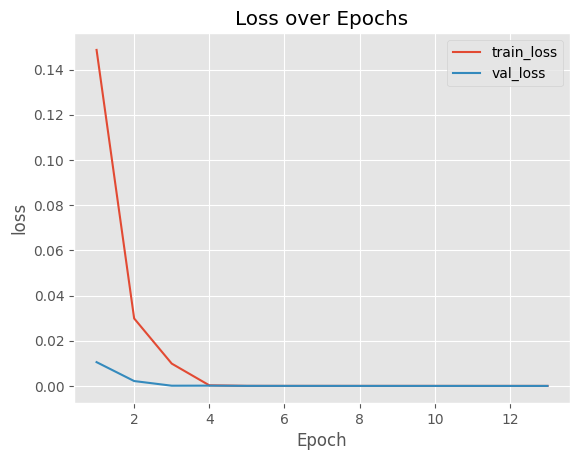

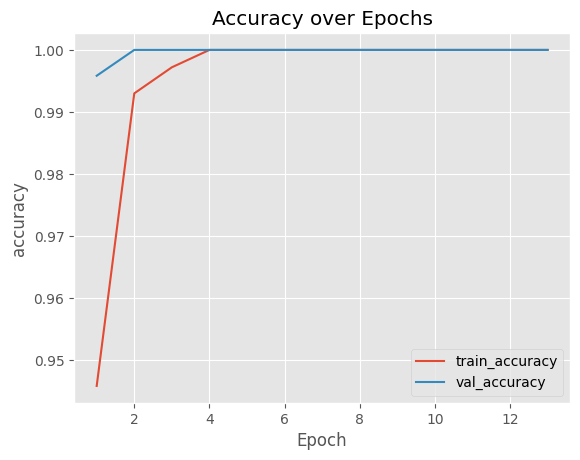

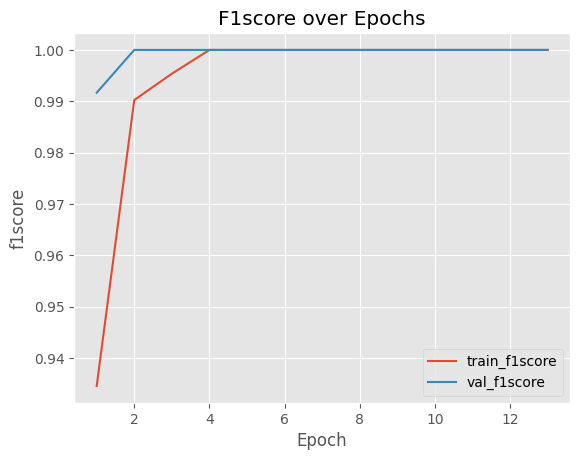

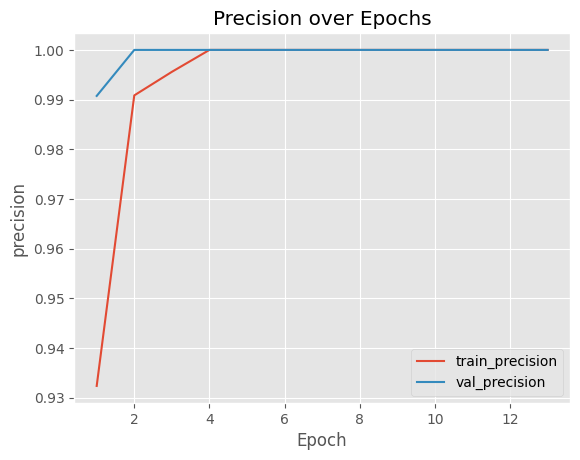

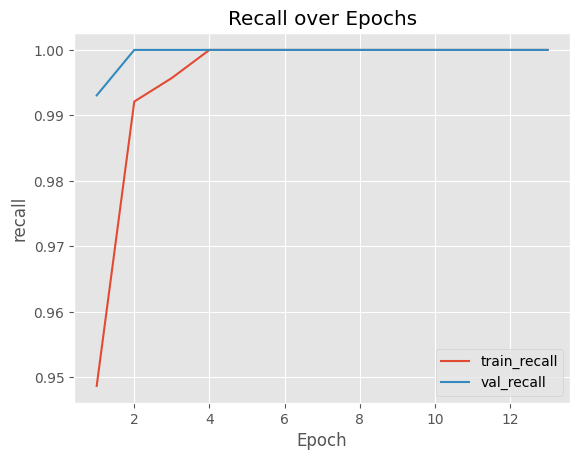

In [23]:
plot_metrics(gru_result)

In [24]:
lstm_model_trainer = ModelTrainer(
    config=config,
    model=lstm_model,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_lstm,
    criterion=criterion,
    scheduler=lstm_scheduler,
    metrics=metrics,
)

lstm_result = lstm_model_trainer.fit()

lstm_result

Training lstm_model:  14%|█▍        | 14/100 [04:10<25:37, 17.87s/it, train_loss=0.0329, train_acc=0.9939, train_f1=0.9904, train_prec=0.9911, train_rec=0.9908, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]


Early stopping triggered at epoch 15 — best val_loss: 0.0000
Best weights restored (val_loss: 0.0000)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,0.119658,0.952804,0.944541,0.945827,0.948728,0.023422,0.991667,0.982407,0.983796,0.982639
1,2,0.017302,0.994860,0.993606,0.994743,0.994289,0.001842,1.000000,1.000000,1.000000,1.000000
2,3,0.026306,0.992056,0.986105,0.986319,0.988058,0.027987,0.991667,0.982407,0.983796,0.982639
3,4,0.025566,0.992523,0.989942,0.991109,0.991141,0.001647,1.000000,1.000000,1.000000,1.000000
4,5,0.009383,0.997196,0.996202,0.997015,0.996301,0.000044,1.000000,1.000000,1.000000,1.000000
5,6,0.006379,0.997664,0.996544,0.996593,0.997307,0.000035,1.000000,1.000000,1.000000,1.000000
6,7,0.005237,0.999533,0.999585,0.999611,0.999740,0.024033,0.995833,0.995833,0.996528,0.996528
7,8,0.065174,0.986449,0.978653,0.980296,0.980724,0.208446,0.950000,0.934987,0.946470,0.941262
8,9,0.034873,0.991121,0.987339,0.988376,0.989291,0.092952,0.983333,0.969511,0.969907,0.973090
9,10,0.015509,0.995794,0.994452,0.995554,0.994678,0.000022,1.000000,1.000000,1.000000,1.000000


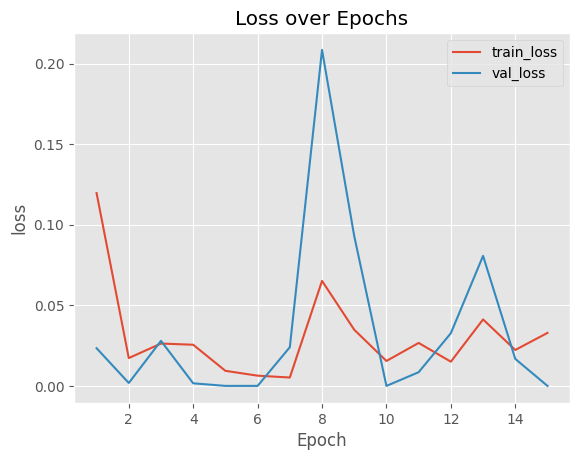

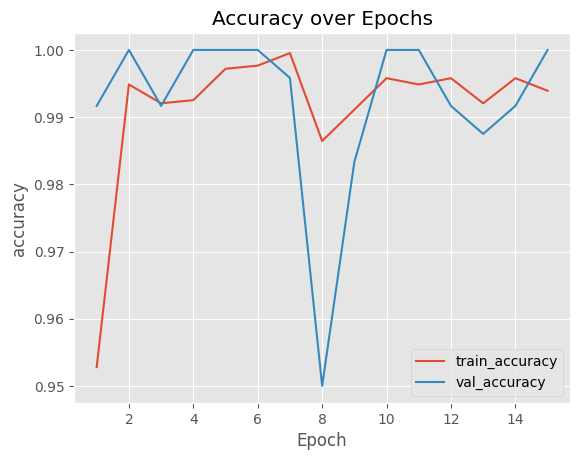

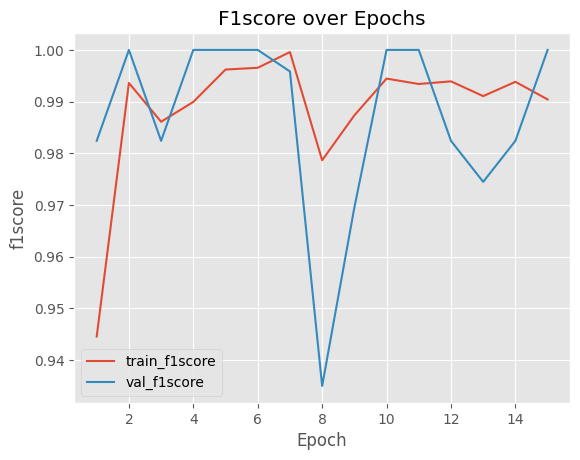

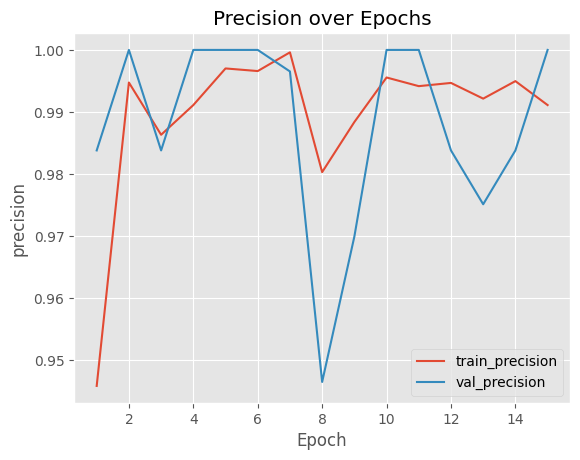

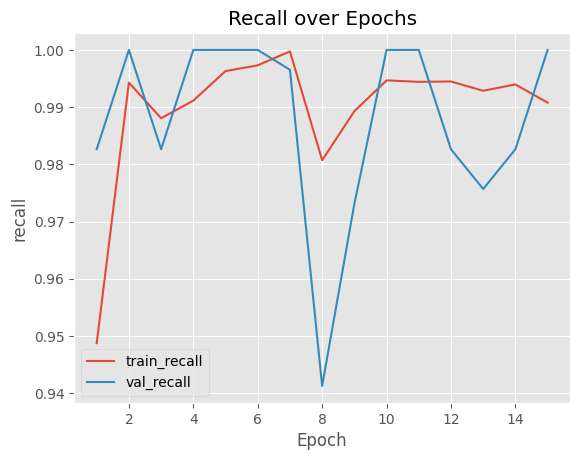

In [25]:
plot_metrics(lstm_result)

In [26]:
lstm_gru_model_trainer = ModelTrainer(
    config=config,
    model=lstm_gru_model,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_lstm_gru,
    criterion=criterion,
    scheduler=lstm_gru_scheduler,
    metrics=metrics,
)

lstm_gru_result = lstm_gru_model_trainer.fit()

lstm_gru_result

Training lstm_gru_model:  12%|█▏        | 12/100 [06:33<48:06, 32.80s/it, train_loss=0.0000, train_acc=1.0000, train_f1=1.0000, train_prec=1.0000, train_rec=1.0000, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]


Early stopping triggered at epoch 13 — best val_loss: 0.0000
Best weights restored (val_loss: 0.0000)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,0.094746,0.968224,0.958224,0.957795,0.963104,5.582585e-02,0.991667,0.982407,0.983796,0.982639
1,2,0.033829,0.991589,0.986337,0.987825,0.987636,2.698334e-03,1.000000,1.000000,1.000000,1.000000
2,3,0.012664,0.995794,0.994022,0.994354,0.994938,4.145333e-05,1.000000,1.000000,1.000000,1.000000
3,4,0.000045,1.000000,1.000000,1.000000,1.000000,1.665724e-05,1.000000,1.000000,1.000000,1.000000
4,5,0.000018,1.000000,1.000000,1.000000,1.000000,1.002842e-05,1.000000,1.000000,1.000000,1.000000
5,6,0.000011,1.000000,1.000000,1.000000,1.000000,6.386933e-06,1.000000,1.000000,1.000000,1.000000
6,7,0.000007,1.000000,1.000000,1.000000,1.000000,4.408008e-06,1.000000,1.000000,1.000000,1.000000
7,8,0.000005,1.000000,1.000000,1.000000,1.000000,3.159338e-06,1.000000,1.000000,1.000000,1.000000
8,9,0.000003,1.000000,1.000000,1.000000,1.000000,2.389463e-06,1.000000,1.000000,1.000000,1.000000
9,10,0.000002,1.000000,1.000000,1.000000,1.000000,1.832665e-06,1.000000,1.000000,1.000000,1.000000


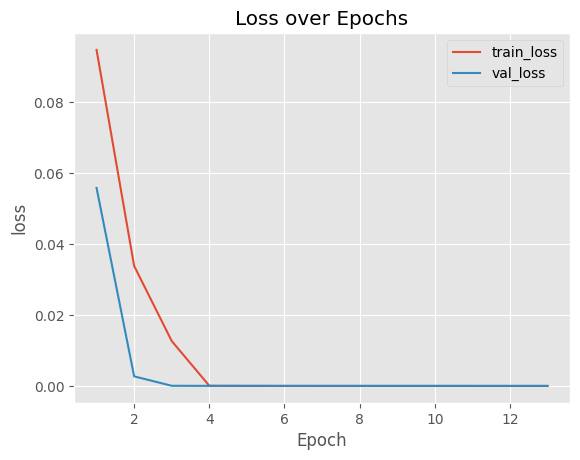

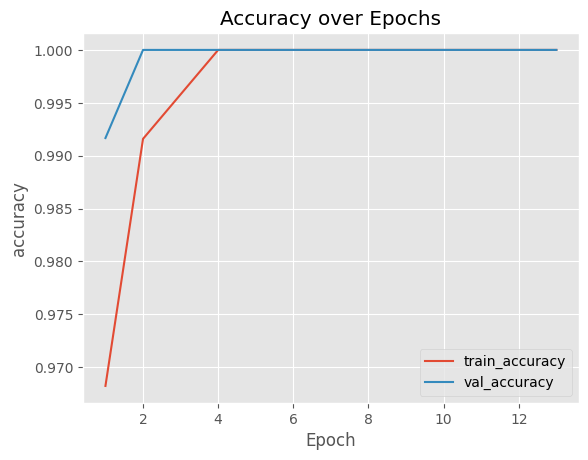

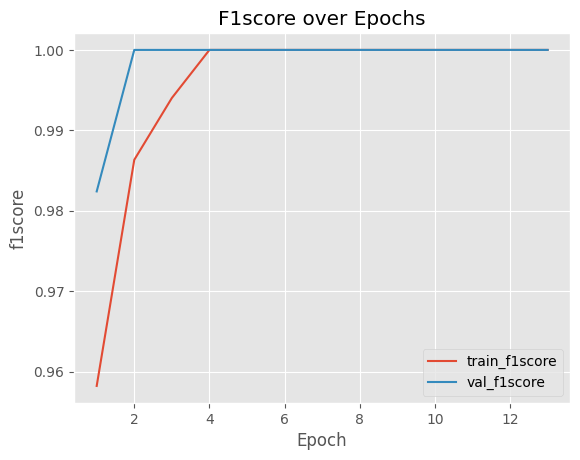

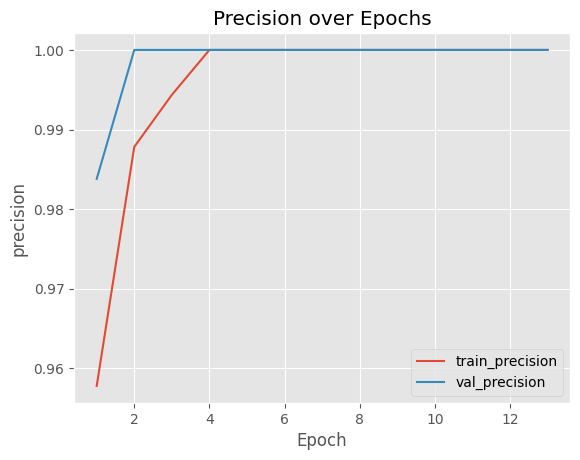

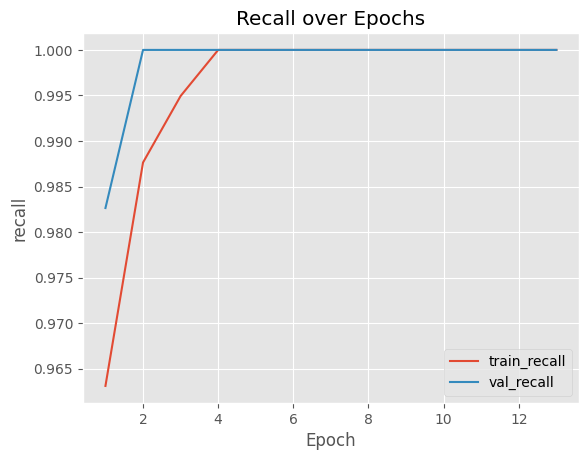

In [27]:
plot_metrics(lstm_gru_result)

In [28]:
rotational_pe_model_trainer = ModelTrainer(
    config=config,
    model=audio_model_rotational_pe,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_model_rotational_pe,
    criterion=criterion,
    scheduler=rotational_pe_scheduler,
    metrics=metrics,
)

rotational_pe_result = rotational_pe_model_trainer.fit()

rotational_pe_result

Training rotational_pe:  10%|█         | 10/100 [06:49<1:01:21, 40.91s/it, train_loss=0.0000, train_acc=1.0000, train_f1=1.0000, train_prec=1.0000, train_rec=1.0000, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]



Early stopping triggered at epoch 11 — best val_loss: 0.0000
Best weights restored (val_loss: 0.0000)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,2.426327e-01,0.968224,0.962303,0.963584,0.966874,0.000000e+00,1.0,1.0,1.0,1.0
1,2,4.974964e-02,0.997664,0.996929,0.997274,0.997209,2.944179e-06,1.0,1.0,1.0,1.0
2,3,4.061157e-06,1.000000,1.000000,1.000000,1.000000,1.019059e-06,1.0,1.0,1.0,1.0
3,4,1.802787e-06,1.000000,1.000000,1.000000,1.000000,4.634231e-07,1.0,1.0,1.0,1.0
4,5,9.704239e-07,1.000000,1.000000,1.000000,1.000000,2.339475e-07,1.0,1.0,1.0,1.0
5,6,5.609841e-07,1.000000,1.000000,1.000000,1.000000,1.241761e-07,1.0,1.0,1.0,1.0
6,7,3.467002e-07,1.000000,1.000000,1.000000,1.000000,7.301560e-08,1.0,1.0,1.0,1.0
7,8,2.321192e-07,1.000000,1.000000,1.000000,1.000000,4.669027e-08,1.0,1.0,1.0,1.0
8,9,1.598715e-07,1.000000,1.000000,1.000000,1.000000,3.278254e-08,1.0,1.0,1.0,1.0
9,10,1.190965e-07,1.000000,1.000000,1.000000,1.000000,2.334514e-08,1.0,1.0,1.0,1.0


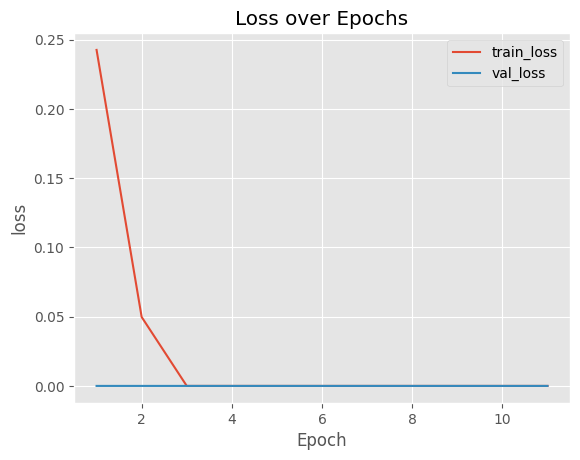

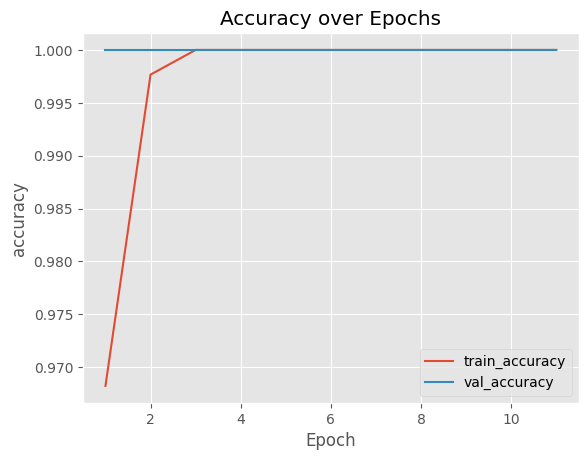

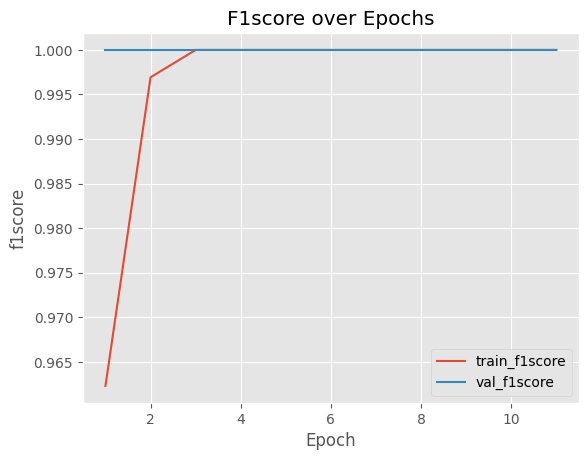

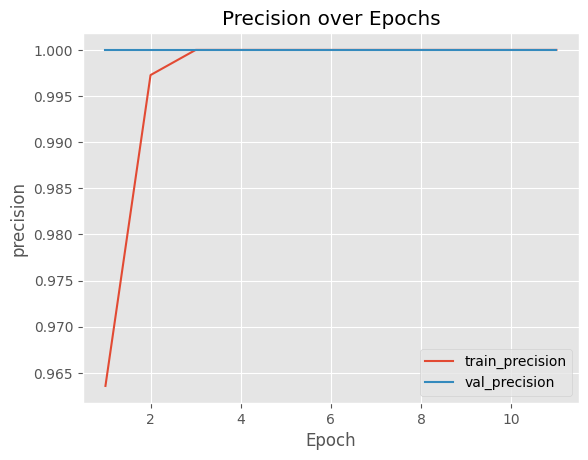

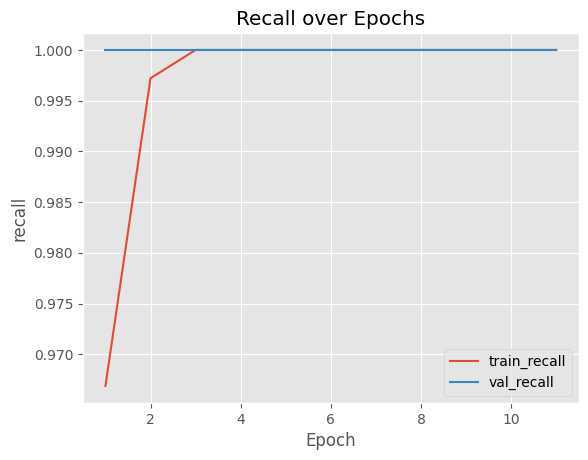

In [29]:
plot_metrics(rotational_pe_result)

In [30]:
sinusoidal_pe_model_trainer = ModelTrainer(
    config=config,
    model=audio_model_sinusodal_pe,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_model_sinusodal_pe,
    criterion=criterion,
    scheduler=sinusoidal_pe_scheduler,
    metrics=metrics,
)

sinusoidal_pe_result = sinusoidal_pe_model_trainer.fit()

sinusoidal_pe_result

Training sinusodal_pe:  10%|█         | 10/100 [06:36<59:31, 39.68s/it, train_loss=0.0000, train_acc=1.0000, train_f1=1.0000, train_prec=1.0000, train_rec=1.0000, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]



Early stopping triggered at epoch 11 — best val_loss: 0.0000
Best weights restored (val_loss: 0.0000)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,9.508710e-02,0.979907,0.976445,0.977369,0.97868,3.332889e-07,1.0,1.0,1.0,1.0
1,2,3.793521e-07,1.000000,1.000000,1.000000,1.00000,2.369282e-07,1.0,1.0,1.0,1.0
2,3,2.402008e-07,1.000000,1.000000,1.000000,1.00000,1.360972e-07,1.0,1.0,1.0,1.0
3,4,1.355865e-07,1.000000,1.000000,1.000000,1.00000,7.698931e-08,1.0,1.0,1.0,1.0
4,5,7.904575e-08,1.000000,1.000000,1.000000,1.00000,4.619359e-08,1.0,1.0,1.0,1.0
5,6,4.868640e-08,1.000000,1.000000,1.000000,1.00000,3.129243e-08,1.0,1.0,1.0,1.0
6,7,3.152918e-08,1.000000,1.000000,1.000000,1.00000,1.937151e-08,1.0,1.0,1.0,1.0
7,8,2.205929e-08,1.000000,1.000000,1.000000,1.00000,1.192093e-08,1.0,1.0,1.0,1.0
8,9,1.676729e-08,1.000000,1.000000,1.000000,1.00000,9.437402e-09,1.0,1.0,1.0,1.0
9,10,1.348067e-08,1.000000,1.000000,1.000000,1.00000,6.457169e-09,1.0,1.0,1.0,1.0


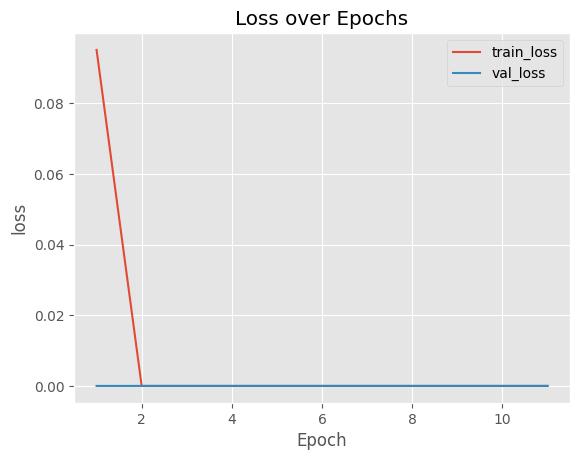

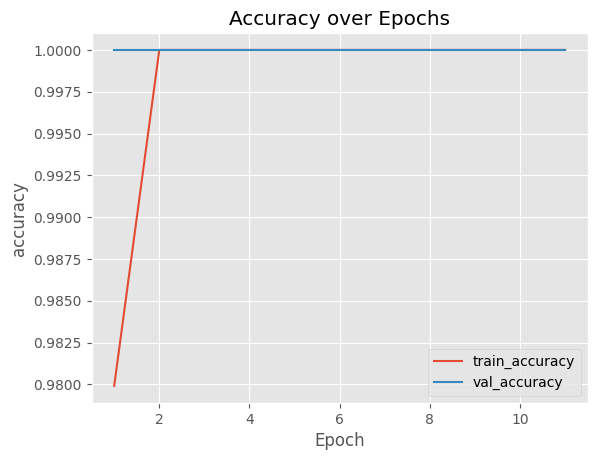

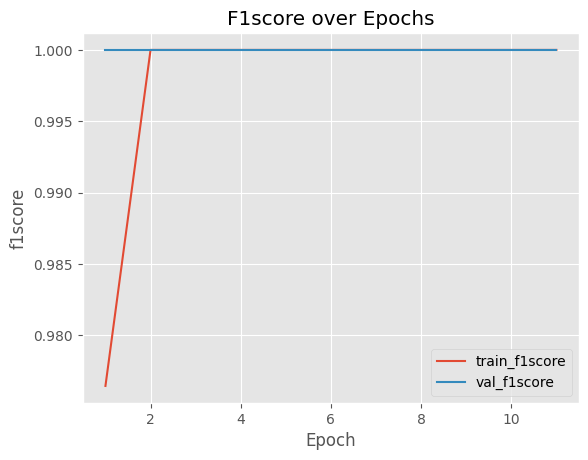

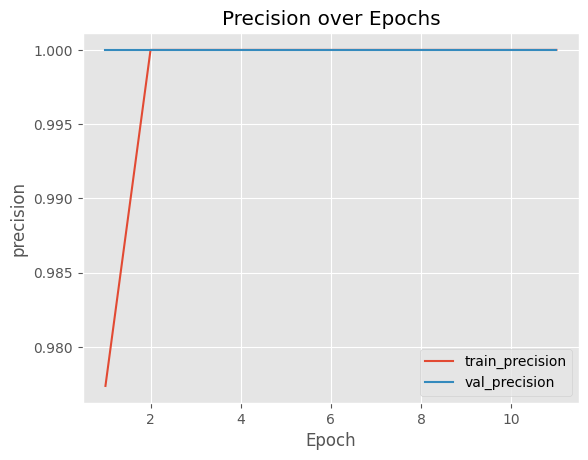

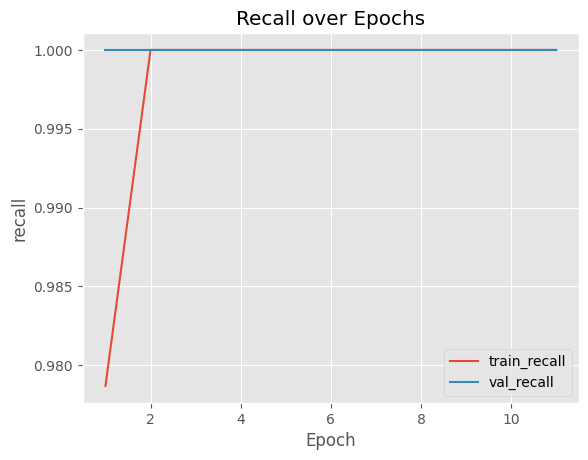

In [31]:
plot_metrics(sinusoidal_pe_result)

In [32]:
relative_pe_model_trainer = ModelTrainer(
    config=config,
    model=audio_model_relative_pe,
    train_dl=train_dl,
    val_dl=val_dl,
    optimizer=optim_model_relative_pe,
    criterion=criterion,
    scheduler=relative_pe_scheduler,
    metrics=metrics,
)

relative_pe_result = relative_pe_model_trainer.fit()

relative_pe_result

Training relative_pe:  10%|█         | 10/100 [08:18<1:14:42, 49.81s/it, train_loss=0.0000, train_acc=1.0000, train_f1=1.0000, train_prec=1.0000, train_rec=1.0000, val_loss=0.0000, val_acc=1.0000, val_f1=1.0000, val_prec=1.0000, val_rec=1.0000]



Early stopping triggered at epoch 11 — best val_loss: 0.0000
Best weights restored (val_loss: 0.0000)


,epoch,train_total_loss,train_total_accuracy,train_total_f1score,train_total_precision,train_total_recall,val_total_loss,val_total_accuracy,val_total_f1score,val_total_precision,val_total_recall
0,1,1.712501e-01,0.97243,0.966112,0.966816,0.971833,4.967053e-10,1.0,1.0,1.0,1.0
1,2,1.173837e-06,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
2,3,6.322341e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
3,4,3.760043e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
4,5,2.456581e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
5,6,1.721284e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
6,7,1.420477e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
7,8,1.253362e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
8,9,1.114099e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0
9,10,1.208795e-08,1.00000,1.000000,1.000000,1.000000,4.967053e-10,1.0,1.0,1.0,1.0


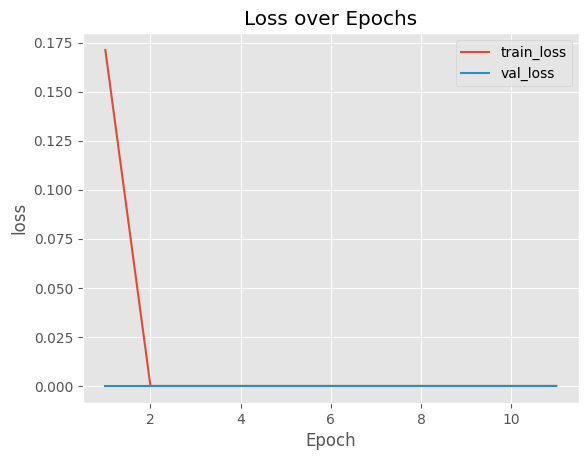

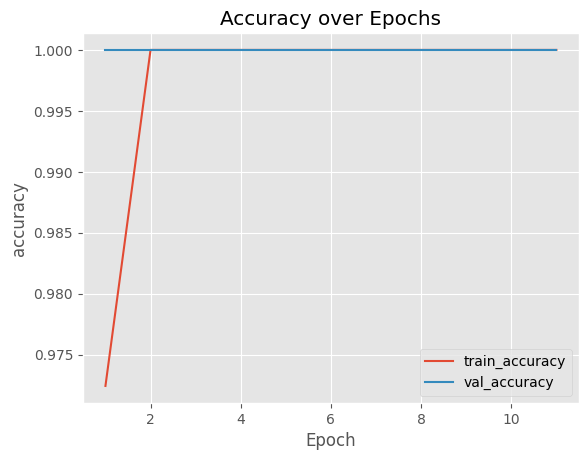

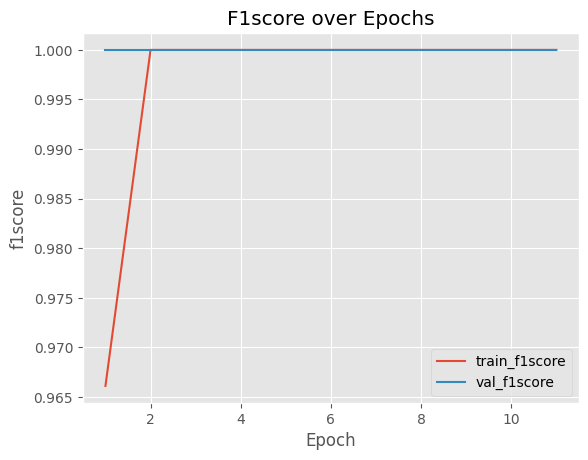

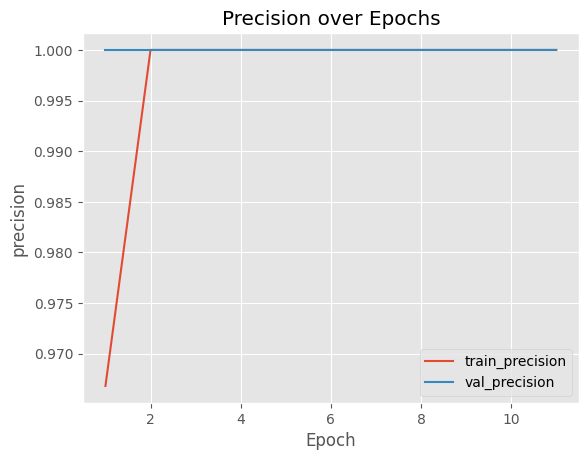

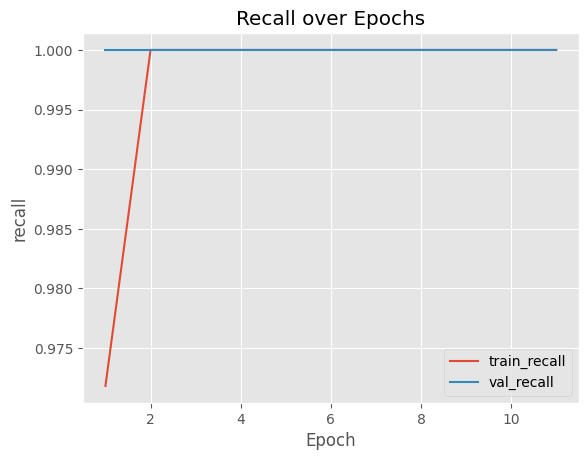

In [33]:
plot_metrics(relative_pe_result)